In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.over_sampling import SMOTE

In [2]:
# 2. Load your data
df = pd.read_csv("2_preprocessed_encoded.csv")  # Replace with actual file
X = df.drop("target", axis=1)
y = df["target"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [4]:
df.shape

(48790, 22)

In [6]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((39032, 21), (9758, 21), (39032,), (9758,))

In [7]:
# 4. Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 5. Apply SMOTE to training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [9]:
# 6. Initialize Decision Tree
dt = DecisionTreeClassifier(random_state=42)

In [10]:
# 7. Fast 10-fold Cross-Validation
cv_scores = cross_val_score(dt, X_train_resampled, y_train_resampled, cv=10, scoring='accuracy')
print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

CV Scores: [0.76187268 0.75884136 0.7596834  0.87066352 0.88748526 0.88344282
 0.88697996 0.8819269  0.88411656 0.89304362]
Mean CV Accuracy: 0.8468056078665439


In [11]:
# 8. Hyperparameter Tuning
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_resampled, y_train_resampled)
print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'min_samples_split': 2}


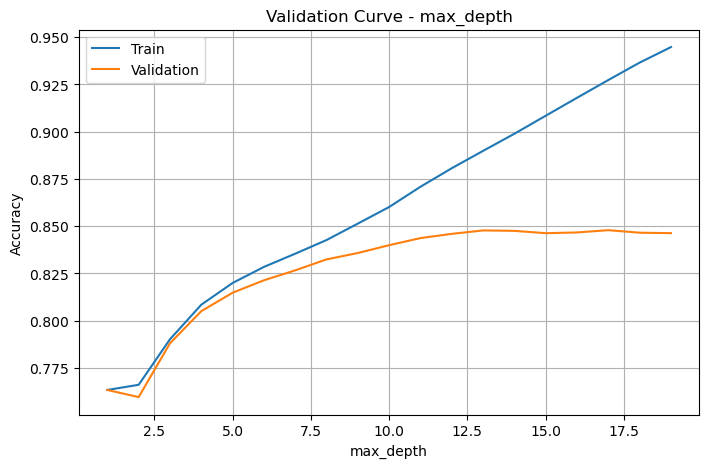

In [12]:
# 9. Validation Curve
param_range = range(1, 20)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train_resampled, y_train_resampled,
    param_name="max_depth", param_range=param_range,
    cv=5, scoring="accuracy"
)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_scores.mean(axis=1), label="Train")
plt.plot(param_range, val_scores.mean(axis=1), label="Validation")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Curve - max_depth")
plt.grid()
plt.show()

In [13]:
# 10. Train final model with best params
dt_final = DecisionTreeClassifier(**grid.best_params_, random_state=42)
dt_final.fit(X_train_resampled, y_train_resampled)

# 11. Evaluation on Test Set
y_pred = dt_final.predict(X_test_scaled)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86      7422
           1       0.56      0.61      0.59      2336

    accuracy                           0.79      9758
   macro avg       0.72      0.73      0.72      9758
weighted avg       0.80      0.79      0.80      9758

Confusion Matrix:
 [[6300 1122]
 [ 902 1434]]
Test Accuracy: 0.7925804468128715


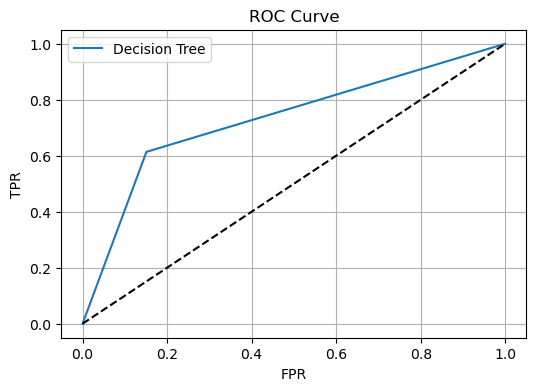

ROC-AUC Score: 0.7313228235752279


In [14]:
# 12. ROC Curve
y_prob = dt_final.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.grid()
plt.legend()
plt.show()
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))